In [76]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install lightgbm
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('../data/energy_data.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [80]:
df.nunique()

date           19735
Appliances        92
lights             8
T1               722
RH_1            2547
T2              1650
RH_2            3376
T3              1426
RH_3            2618
T4              1390
RH_4            2987
T5              2263
RH_5            7571
T6              4446
RH_6            9709
T7              1955
RH_7            5891
T8              2228
RH_8            6649
T9               924
RH_9            3388
T_out           1730
Press_mm_hg     2189
RH_out           566
Windspeed        189
Visibility       413
Tdewpoint       1409
rv1            19735
rv2            19735
dtype: int64

In [81]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[us]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7         19

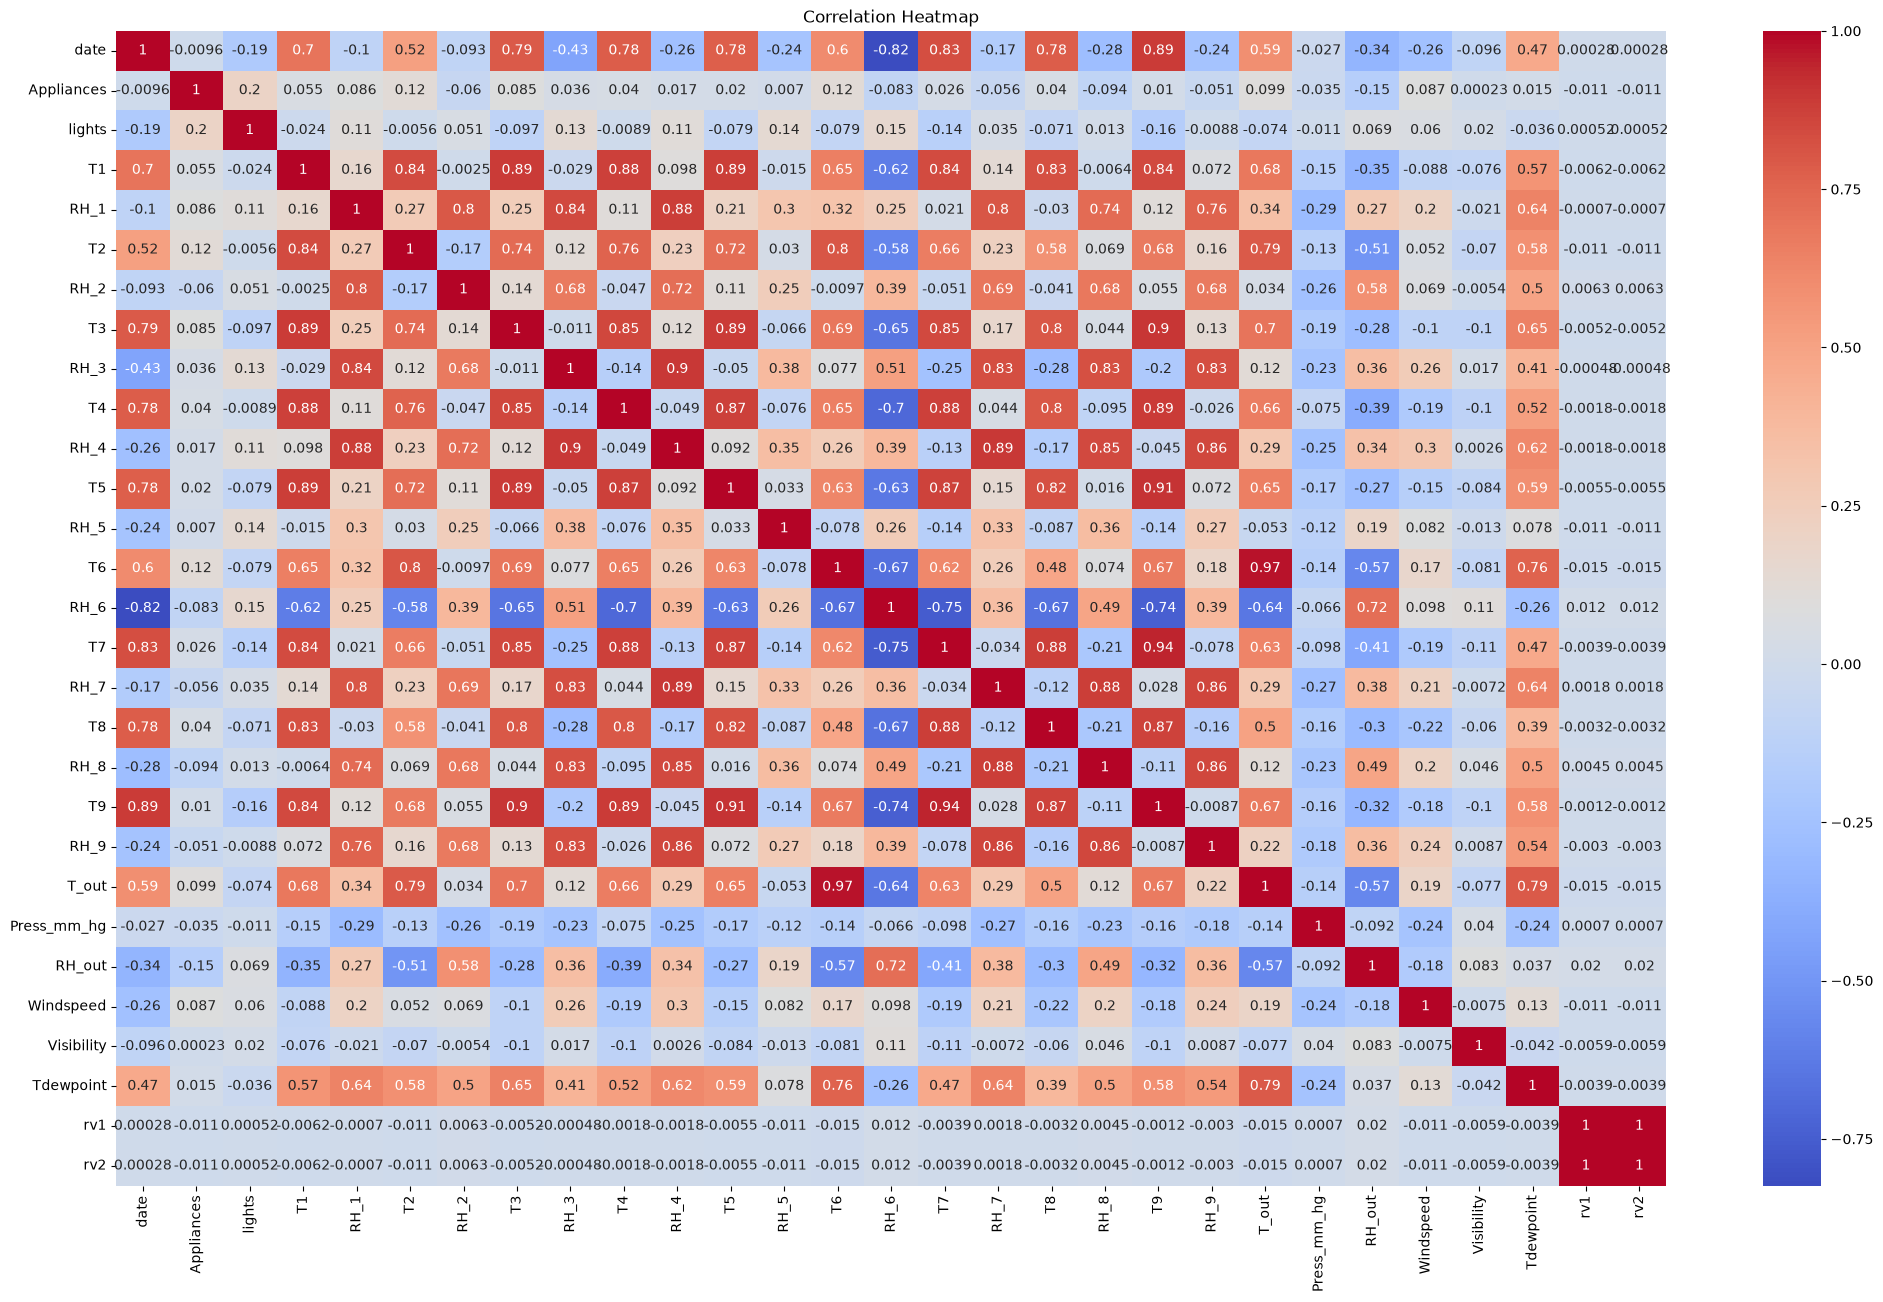

In [83]:
df_corr = df.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [84]:
df=df.drop(columns='rv2')

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[us]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7         19

In [86]:
df = df.sort_values('date').reset_index(drop=True)

In [87]:
def add_time_features(df, timestamp_col="date"):
    df["hour"] = df[timestamp_col].dt.hour
    df["day_of_week"] = df[timestamp_col].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["month"] = df[timestamp_col].dt.month
    return df



In [88]:
df = add_time_features(df)

In [89]:
df.describe()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,hour,day_of_week,is_weekend,month
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:29:59.999999,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,11.502002,2.977249,0.277274,3.101647
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.000000,0.000000,0.000000,1.000000
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,6.000000,1.000000,0.000000,2.000000
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,12.000000,3.000000,0.000000,3.000000
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,17.000000,5.000000,1.000000,4.000000
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,23.000000,6.000000,1.000000,5.000000
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,6.921953,1.985617,0.447664,1.339200


In [90]:
# ---------- 2. NEW: lag + rolling features on Appliances ----------
# data is at 10-minute intervals -> 6 steps = 1 hour
df["app_lag1"] = df["Appliances"].shift(1)    # t-10 min
df["app_lag2"] = df["Appliances"].shift(2)    # t-20 min
df["app_lag3"] = df["Appliances"].shift(3)    # t-30 min
df["app_lag6"] = df["Appliances"].shift(6)    # t-60 min
df["app_roll_mean_1h"] = df["Appliances"].shift(1).rolling(6).mean()
df["app_roll_std_1h"] = df["Appliances"].shift(1).rolling(6).std()
df["app_roll_mean_3h"] = df["Appliances"].shift(1).rolling(18).mean()

# drop the warm-up rows that now contain NaNs from lagging/rolling
df = df.dropna().reset_index(drop=True)

In [91]:
y = np.log1p(df["Appliances"])
x = df.drop(columns=["Appliances", "date"])

In [92]:
split_date = df["date"].max() - pd.Timedelta(weeks=4)

train_idx = df["date"] < split_date
test_idx = df["date"] >= split_date

X_train, X_test = x[train_idx], x[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [93]:
num_col = x.select_dtypes(include=["int64", "float64"]).columns
num_col

Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1',
       'is_weekend', 'app_lag1', 'app_lag2', 'app_lag3', 'app_lag6',
       'app_roll_mean_1h', 'app_roll_std_1h', 'app_roll_mean_3h'],
      dtype='str')

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_col)],
    remainder="passthrough"
)

In [95]:
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (15684, 37), Test size: (4033, 37)


In [96]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=7, weights="distance", n_jobs=-1),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        n_jobs=-1, random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        n_jobs=-1, random_state=42
    ),
    "Gradient Boosting (sklearn)": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
        random_state=42, n_jobs=-1, tree_method="hist"
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=20,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

In [97]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
results = []

In [ ]:
for name, model in cv_models.items():
    r2_scores = []
    rmse_scores = []

    # Split training data into folds (each fold respects time order)
    for tr_index, val_index in tscv.split(X_train):
        X_tr = X_train.iloc[tr_index]
        y_tr = y_train.iloc[tr_index]
        X_val = X_train.iloc[val_index]
        y_val = y_train.iloc[val_index]

        # Build and train the pipeline (preprocessing + model)
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_tr, y_tr)

        # Predict and score
        predictions = pipe.predict(X_val)
        r2 = r2_score(y_val, predictions)
        rmse = mean_squared_error(y_val, predictions) ** 0.5

        r2_scores.append(r2)
        rmse_scores.append(rmse)

    # Average the scores across folds
    avg_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    avg_rmse = np.mean(rmse_scores)

    cv_results.append({
        "Model": name,
        "CV_R2_mean": avg_r2,
        "CV_R2_std": std_r2,
        "CV_RMSE_mean": avg_rmse,
    })

    print(f"[CV] {name:28s} | R2={avg_r2:.3f} (+/-{std_r2:.3f}) | RMSE={avg_rmse:.3f}")

# Put results in a table, best model first
cv_df = pd.DataFrame(cv_results).sort_values("CV_R2_mean", ascending=False)
print("\n=== TimeSeriesSplit CV ranking (train data only) ===")
print(cv_df.to_string(index=False))